# **Business Recquirements.**
**Task 1:** *Customers Segment analysis to get to know about our customers preferences*.  

**Task 2:** *Trend analysis to get to know about Company to find any patterns.*

In [1]:
# Importing necessary Libraries.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px

 **Loading and Merging the Datasets.**

In [2]:
Purchase_Behaviour= pd.read_csv("QVI_purchase_behaviour.csv") # Loading the Purchase Behaviour Csv data file.
Transaction_data= pd.read_excel("QVI_transaction_data.xlsx") # Loading the Tarnsaction Data Excel file.

# Merging both Datasets into one using Left Join.
Merged_df= pd.merge(left=Transaction_data, right=Purchase_Behaviour,on="LYLTY_CARD_NBR",how="left")
Merged_df.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


# **Data Quality Checks:**
* **Data Types**
* **Null Values**
* **Duplicated Values**
* **Outlier Values**


In [3]:
Merged_df.head(2)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget


In [4]:
# Cheking Column Info.
Merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              264836 non-null  int64  
 1   STORE_NBR         264836 non-null  int64  
 2   LYLTY_CARD_NBR    264836 non-null  int64  
 3   TXN_ID            264836 non-null  int64  
 4   PROD_NBR          264836 non-null  int64  
 5   PROD_NAME         264836 non-null  object 
 6   PROD_QTY          264836 non-null  int64  
 7   TOT_SALES         264836 non-null  float64
 8   LIFESTAGE         264836 non-null  object 
 9   PREMIUM_CUSTOMER  264836 non-null  object 
dtypes: float64(1), int64(6), object(3)
memory usage: 20.2+ MB


In [5]:
# Checking Null Values in the Dataset.
Merged_df.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [6]:
# Checking Duplicated Values in the Dataset.
print(f"No. of Duplicated Values :{Merged_df.duplicated().sum()}")

No. of Duplicated Values :1


In [7]:
# Checking the count of Outlier values.
Outlier_Values=[]
Q1= Merged_df["TOT_SALES"].quantile(0.25)
Q3= Merged_df["TOT_SALES"].quantile(0.75)
IQR= Q3-Q1
Lower_Bound= Q1 - 1.5*IQR
Upper_Bound= Q3 + 1.5*IQR

for value in Merged_df["TOT_SALES"]:
    if value < Lower_Bound:
        Outlier_Values.append(value)
    elif value > Upper_Bound:
        Outlier_Values.append(value)

print(f"The count of Outlier Values are {len(Outlier_Values)}")


The count of Outlier Values are 578


# **Summary of Data Quality Checks:**
1. **Data Types:**  
* **Date column** needs to be changed from int to datetime dtype for the Analysis.  
* **Column Names** need to be changed for better readablity.  
* **Object to Categorical dtype** for reducing the Data Size. 


2. **NUll Values: 0**
3. **Duplicated Values: 1**
4. **Outlier Values: 578**

In [8]:
# Renaming Columns.
Merged_df.rename(columns={"DATE":"Date","PROD_NAME":"Product_Name","PROD_QTY":"Quantity","LIFESTAGE":"Customer_Type","PREMIUM_CUSTOMER":"Customer_Segment","TOT_SALES":"Sales"},inplace=True)

# # Changing the datatype of the Date column from int to datetime .
Merged_df["Date"] = pd.to_datetime(Merged_df["Date"], unit="D", origin="1899-12-30")

# Changing dtype from object to category.
Merged_df["Customer_Type"]= Merged_df["Customer_Type"].astype("category")
Merged_df["Customer_Segment"]= Merged_df["Customer_Segment"].astype("category")


# Removing Duplicated Values.
Merged_df.drop_duplicates(inplace=True)
# Confirming no Duplicated Values in the Dataset.
print(f"No. of duplicated Values after action:{Merged_df.duplicated().sum()}")

No. of duplicated Values after action:0


In [9]:
Merged_df.head()

,Date,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,Product_Name,Quantity,Sales,Customer_Type,Customer_Segment
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


# **KPI's:**  
* **Total Sales**= $19 Million  
* **Average Sales**= $7.30  
* **Total Quantity Sold**= 505K  
* **Average Quantity Sold**= 1.90


In [10]:
print(f"Total Sales:{Merged_df["Sales"].sum()}")
print(f"Average Sales:{Merged_df["Sales"].mean()}")
print(f"Total Quantity:{Merged_df["Quantity"].sum()}")
print(f"Average Quantity:{Merged_df["Quantity"].mean()}")

Total Sales:1934408.9999999998
Average Sales:7.3042045046916
Total Quantity:505122
Average Quantity:1.9073083240508242


# **Customer Analysis**

Text(0, 0.5, '')

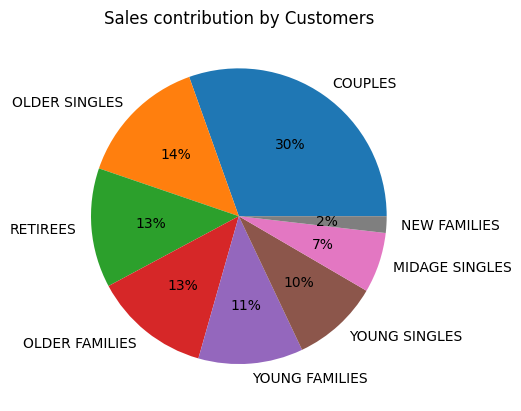

In [11]:
# Sales Distribution by Customer Type.
splited_data = Merged_df["Customer_Type"].str.split("/")
exploded_result= splited_data.explode().reset_index(drop=True).value_counts()
exploded_result.plot(kind="pie",autopct="%1.0f%%")
plt.title("Sales contribution by Customers")
plt.ylabel("")


Text(0.5, 1.0, 'Sales by Customer Types')

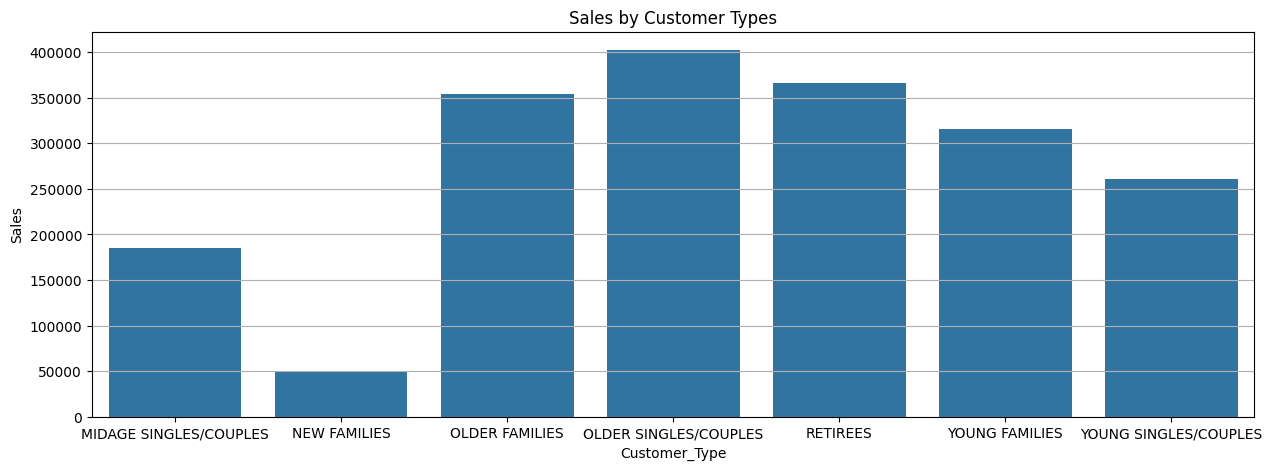

In [12]:
# Sales by Customer Types.

plt.figure(figsize=(15,5))
plt.grid()
sns.barplot(data=Merged_df,x="Customer_Type",y="Sales",estimator="sum",errorbar=None)
plt.title("Sales by Customer Types")

Text(0.5, 1.0, 'Sales by Customer Segments')

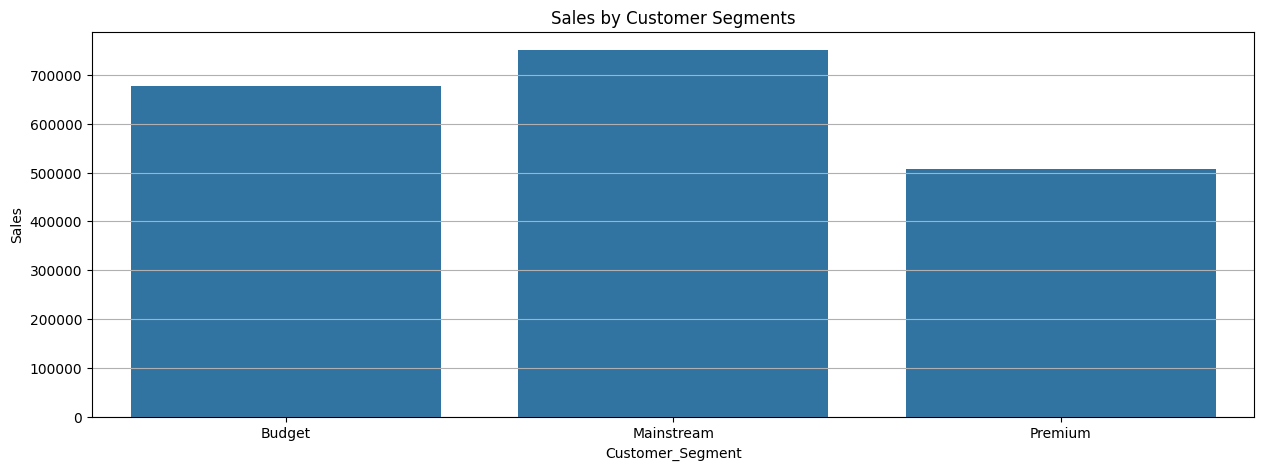

In [14]:
# Sales by Customer Segments.
plt.figure(figsize=(15,5))
plt.grid()
sns.barplot(data=Merged_df, x="Customer_Segment",y="Sales",estimator="sum",errorbar=None)
plt.title("Sales by Customer Segments")


In [26]:
o= Merged_df.groupby(by=["Customer_Type","Customer_Segment"])["Sales"].sum().reset_index()

px.bar(data_frame=o,x="Customer_Type",y="Sales",color="Customer_Segment",barmode="group")

C:\Users\Shubham\AppData\Local\Temp\ipykernel_14200\1660221669.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

